In [1]:
from src.data_loader import load_logreturns, load_prices
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm
from scipy.stats import kurtosis
from statsmodels.graphics.tsaplots import plot_acf

# Asset Return Model Comparison: Geometric Brownian Motion vs. Deep Learning
### Summary
- **Data**: S&P-500 daily returns, 2020 - 2026, sourced via yfinance
- **Part 1**: Empirical analysis of return distributions and volatility structure: we reproduce the stylized facts documented in Cont(2001) for our data set
- **Part 2**: GBM calibrated to historical parameters; systematic comparison reveals failure to reproduce heavy tails and volatility clustering
- **Part 3**: Two neural network architectures trained to capture the statistical structure (volatility clustering) GBM misses

## Introduction

Geometric Brownian Motion (GBM) assumes returns are normally distributed and independent. Neither holds empirically. This project quantifies how large that gap is and tests whether deep learning can close it.

Our goal for this project is to compare the statistical features of S&P 500 returns to those of GBM and identify the aspects GBM fails to model. We then examine whether a deep learning model can capture some of these statistical features in its place. 

Our motivation for using GBM as our comparison model comes from the Black Scholes options pricing model which uses the GBM as a base and is the basis for the most commonly used options pricing frameworks. 

In this first part we reproduce some of the famous stylized empirical facts from the influential paper, *Empirical properties of asset returns: stylized facts and statistical issues* (Rama Cont, 2001), which highlighted the statistical differences between Gaussian models and empirical asset returns. 

In the second part we calibrate a GBM to the historical data and compare it directly to the empirical results. 

In the third part we implement two neural network architectures trained on S&P-500 time series data to model the statistical aspects the GBM fails to capture.

## Part 1: Empirical Properties of S&P-500 Returns
### Distributional Statistics

We begin by examining the distributional properties of S&P-500 log returns. The GBM model assumes returns are normally distributed. We test this assumption by analyzing the empirical distribution, looking specifically for heavy tails and excess kurtosis, both of which Cont (2001) identifies as universal properties of asset returns.

We first load the log returns of our data, in this case the S&P-500 price data starting in 2020 and create a basic plot.



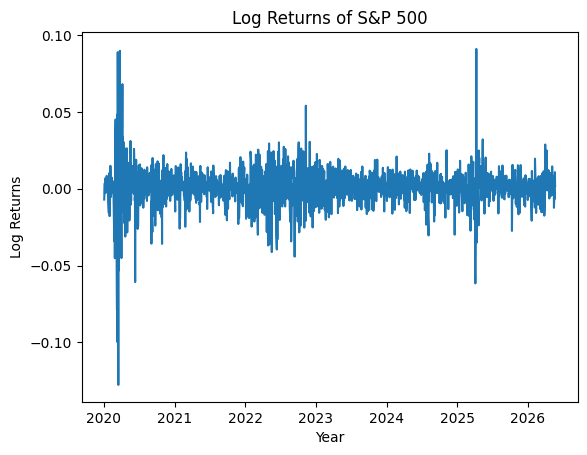

In [2]:
returns = load_logreturns()
prices =  load_prices()

plt.plot(returns)
plt.title("Log Returns of S&P 500")
plt.xlabel("Year")
plt.ylabel("Log Returns")
plt.show()


From visual inspection, volatility clustering appears apparent in the 2020 spike with increased volatility afterwards as well as lower magnitude clustering of large moves at different periods throughout the data.  We will quantify this below in the section "Temporal Characteristics."

To examine the assumption of Gaussian distributed increments we calculate the mean, std, and excess kurtosis so that we can compare the distribution of our data directly with a Gaussian distribution of the same mean and variance.

In [3]:
mean = np.mean(returns)
std = np.std(returns)
excess_kurtosis = kurtosis(returns)
# Since sci-kit calculates excess kurtosis (kurtosis - 3) by default, 
# for better readability we calculate kurtosis
kurtosis_ = excess_kurtosis + 3

print('The mean is:', mean)
print('The standard deviation is:', std)
print('The kurtosis is:', kurtosis_)

The mean is: 0.0005152864726416422
The standard deviation is: 0.01298696916036131
The kurtosis is: 17.818401956462765


We see that the mean is close to 0 relative to the standard deviation. Short term price movements are dominated by noise. 

The standard deviation is large relative to the mean, indicating substantial randomness and uncertainty in daily returns.

Though these two properties could be consistent with GBM the final property shows the first statistical property of our empirical asset data that violate the assumptions underlying GBM:

The S&P 500 time series data shows pronounced evidence of fat tails with kurtosis >> 3. Since Gaussian distributions have excess kurtosis of 3, this means that extreme events happen more often than Gaussian models (like GBM) predict. 

We have already reproduced one of the stylized facts (fat tails) and identified a statistical property our GBM model will fail to replicate. 

To compare our empirical data more directly with a Gaussian distribution we create a plot overlaying our data with a Gaussian distribution of the same mean and variance. 

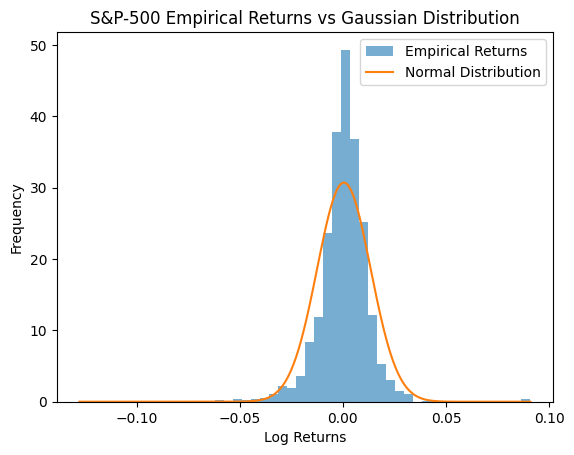

In [4]:
x = np.linspace(returns.min(), returns.max(), 1000)
gauss_y_val = norm.pdf(x, mean, std)

plt.hist(returns,bins=50,density=True, alpha=0.6,label='Empirical Returns')
plt.plot(x, gauss_y_val, label="Normal Distribution")
plt.title("S&P-500 Empirical Returns vs Gaussian Distribution")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

As expected by the kurtosis of the data, we observe sharper peaks and fatter tails compared to the Gaussian benchmark.

The Gaussian model fails to capture the two extremes accurately. It understimates the likelyhood of both tiny movements and huge movements compared to the real observations in the empirical data. On the other hand, the Gaussian model overestimates the likelyhood of mid-sized movements.

Translating this empirical observation into the intuition of financial markets, our empirical data tells us that the market tends to spend a lot of time being relatively quiet while occasionally making huge moves. It alternates between calm regimes and turbulent regimes. This relates directly to the idea of volatility clustering. The Gaussian model assumes constant volatility.

### Temporal Structure

We will examine our data more closely looking for evidence of volatility clustering. To do this we plot the standard deviation over a rolling window of 20 days. This will give us a time series to examine the change of the volatility over time.

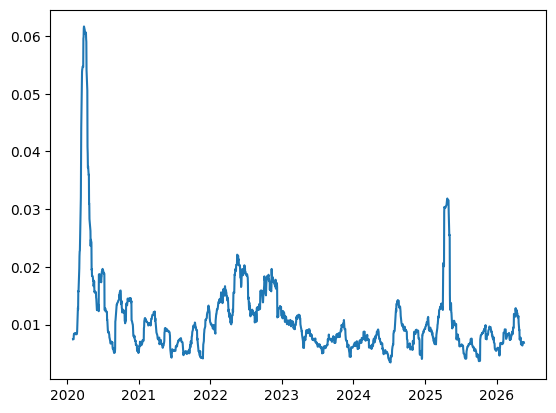

In [5]:
volatility = returns.rolling(20).std()
plt.plot(volatility)
plt.show()


From the plot we can see that the volatility varies significantly over time. 

Periods of higher volatility tend to cluster together, suggesting that variance is time-dependent rather than constant. 

A Gaussian model assumes constant volatility, thus will not be able to capture this statistical property. 

### Autocorrelation

We now wish to examine the predictability of the returns as well as for volatility. For this we examine the autocorrelation of the returns and of the squared returns. Since volatility is related to magnitude, not direction, the squared returns serve as a rough approximation for the volatility:

In [6]:
autocorrelation_returns = returns.autocorr()
autocorrelation_squaredreturns = (returns**2).autocorr()
print('Autocorrelation of returns:', autocorrelation_returns)
print('Autocorrelation of squared returns:', autocorrelation_squaredreturns)

Autocorrelation of returns: -0.16565559908937472
Autocorrelation of squared returns: 0.454829895917528


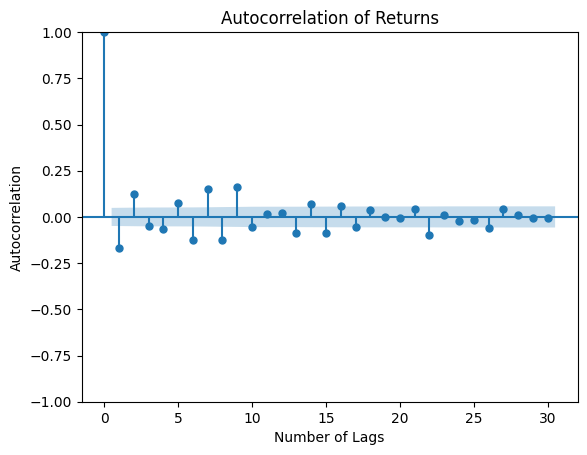

In [7]:
plot_acf(returns, lags=30)
plt.title("Autocorrelation of Returns")
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
plt.show()

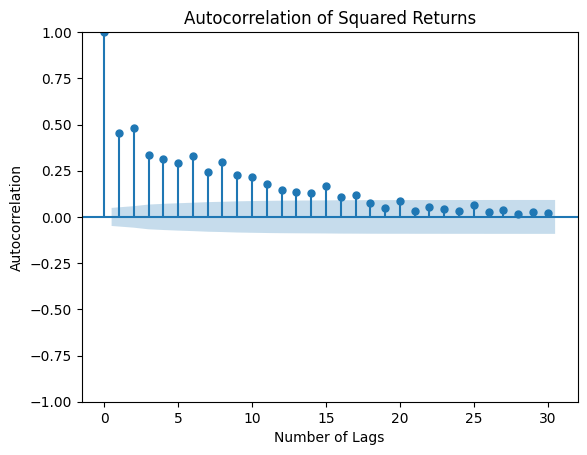

In [8]:
plot_acf(returns**2,lags=30)
plt.title("Autocorrelation of Squared Returns")
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
plt.show()

Comparing the two plots, we notice the ACF plot of the returns appears very noisy with no clear decay pattern. Despite having isolated statistically siginficant autocorellation values outside of the confidence window, the values are still small and are likely a result of noise. This suggests limited linear predictability in returns themselves. 

On the other other hand, the squared returns show consistent statistically significant autocorellation up to about 15 lags with slow linear decay with respect to the number of lags. This behavior is consistent with volatility clustering. 

Taking all these statistical facts together (kurtosis, heavy tails, volatility clustering) the higher order statistics of the S&P-500 demonstrate clearly non-Gaussian behavior. 

We will put these statistical observations to the test directly by building a GBM model and comparing the behavior directly.

## GBM Model
### Distributional Statistics

We import the GBM model. We first compare the prices and log returns simulated by a single GBM path.

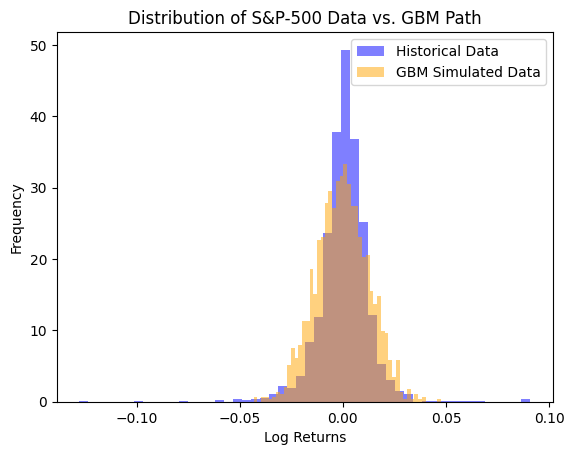

In [9]:
from src.gbm import simulate_GBM
simulated_prices = simulate_GBM(prices, returns)
simulated_logreturns = np.diff(np.log(simulated_prices))
plt.hist(returns, bins=50,alpha=0.5,density=True, color='blue', label="Historical Data")
plt.hist(simulated_logreturns, bins=50, alpha=0.5, density=True, color='orange',label="GBM Simulated Data")
plt.title("Distribution of S&P-500 Data vs. GBM Path")
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()


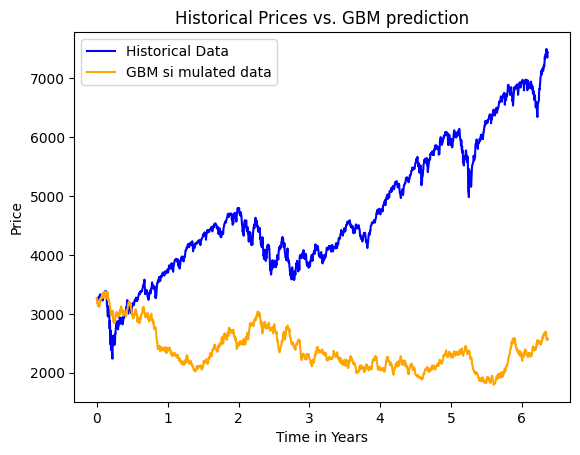

In [10]:
t = np.linspace(0, len(prices)/252, len(prices))
plt.plot(t, prices.values, color='blue', label='Historical Data')
plt.plot(t, simulated_prices, color='orange', label='GBM si mulated data')
plt.title('Historical Prices vs. GBM prediction')
plt.xlabel('Time in Years')
plt.ylabel('Price')
plt.legend()
plt.show()

We notice that the GBM very roughly models the S&P-500, generally following the same trend. The histogram comparison shows, similarily to the Gaussian overlay, that the true S&P-500 data has sharper peaks, heavier tails and less "mid-sized" movements compared to the GBM. 

We now increase the number of simulations in a Monte-Carlo type simulation and determine the average path of our GBM, plotting each simulation in comparison to the true S&P-500 data. 

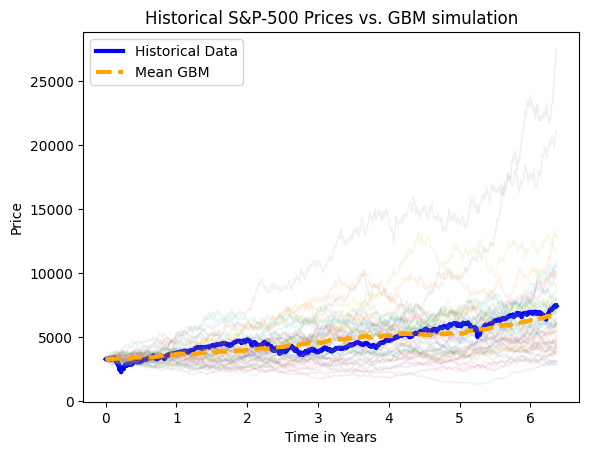

In [11]:
#number or simulations
n = 50
plt.plot(t, prices.values, color='blue',linewidth=3, label='Historical Data')
average_simprices = np.zeros((len(prices)))
all_sim_returns = []
for i in range(n):
    prices_estimate = simulate_GBM(prices, returns)
    average_simprices = (average_simprices + prices_estimate)
    sim_log_returns = np.diff(np.log(prices_estimate))
    all_sim_returns.extend(sim_log_returns)
    plt.plot(t, prices_estimate, alpha=0.1, linewidth=1)
average_simprices = average_simprices * 1/n 
plt.plot(t, average_simprices,color='orange', linewidth=3, linestyle='--', label='Mean GBM')  
plt.title("Historical S&P-500 Prices vs. GBM simulation")
plt.xlabel('Time in Years')
plt.ylabel('Price')
plt.legend()
plt.show()

We now compare the histograms of the log returns of the historical data vs the simulated GBM paths. 

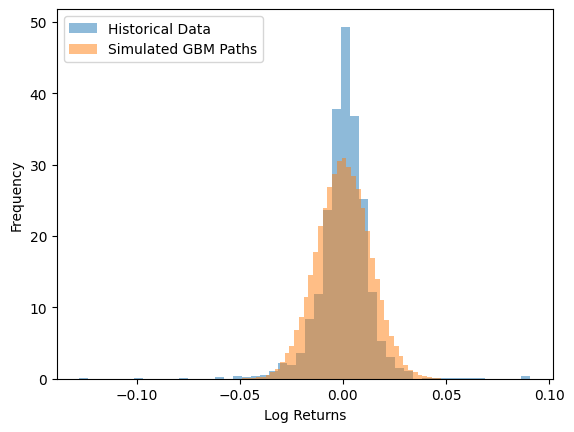

In [12]:
plt.hist(returns, bins=50, density=True, alpha=0.5,label="Historical Data")
plt.hist(all_sim_returns, bins=50,density=True,alpha=0.5,label='Simulated GBM Paths')
plt.xlabel("Log Returns")
plt.ylabel("Frequency")
plt.legend()
plt.show()

Here we see that by increasing the number of GBM paths we approach a Gaussian distribution more closely. As predicted by our analysis of the historical data, the GBM model generally underestimates extreme daily movements (very small amplitude, or very large amplitude) and overestimates mid-sized movements. 

We now evaluate the kurtosis of our simulated returns.

In [13]:
all_simulated_excess_kurtosis = kurtosis(all_sim_returns)
# We convert the excess kurtosis calculated by default by scikit to kurtosis for better readability
all_simulated_kurtosis = all_simulated_excess_kurtosis + 3
simulated_excess_kurtosis = kurtosis(simulated_logreturns)
simulated_kurtosis = simulated_excess_kurtosis + 3
print('The kurtosis of the log returns of a single simulated GBM path is:', simulated_kurtosis)
print('The kurtosis of the log returs of many simulated GBM paths is:', all_simulated_kurtosis)

The kurtosis of the log returns of a single simulated GBM path is: 3.033395812938548
The kurtosis of the log returs of many simulated GBM paths is: 3.000952275506739


As expected the kurtosis of the simulated GBM paths is very close to 3
 only showing negligible evidence of heavy tails.

Now that we have compared the distributional statistics of the data vs. the GBM model we examine the temporal structure. 

### Temporal Structure

We compare the rolling volatility over a moving window of 20 days of our simulated GBM path to that of the S&P-500 data.

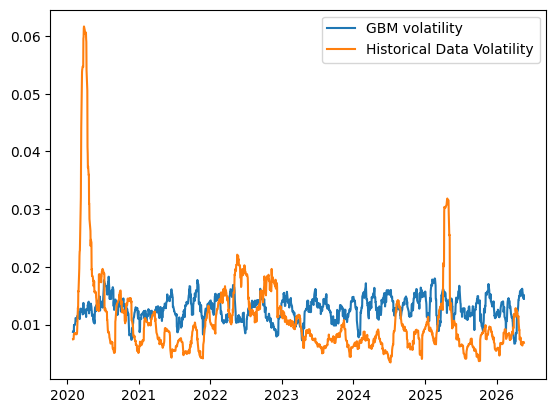

In [14]:
sim_log_returns = pd.Series(sim_log_returns, index=returns.index)
volatility_gbm = sim_log_returns.rolling(20).std()
plt.plot(volatility_gbm, label="GBM volatility")
plt.plot(volatility, label="Historical Data Volatility")
plt.legend()
plt.show()

Compared to the volatility of the historical data, the volatility of the simulated GBM path is relatively constant with only small fluctuations. The volatility of the historical data is roughly centered around the volatility of the GBM but exhibits much larger deviations. 

Since the GBM model is calibrated with the empirical standard deviation, the GBM model can capture the overall fluctuation magnitude but assumes constant volatility, which is not true for the historical data.

As we did for the historical data, we calculate the autocorrelation of the returns and of the squared returns. 

In [15]:
autocorrelation_gbmreturns = sim_log_returns.autocorr()
autocorrelation_squaredgbmreturns = (sim_log_returns**2).autocorr()
print('Autocorrelation of returns:', autocorrelation_gbmreturns)
print('Autocorrelation of squared returns:', autocorrelation_squaredgbmreturns)

Autocorrelation of returns: 0.010188836782743464
Autocorrelation of squared returns: -0.012052442673677853


Neither returns nor squared returns show significant autocorrelation. In contrast to the historical data, we see no signs of volatility clustering. GBM assumes constant volatility.  

We plot the ACF plots of returns and squared returns to examine this more deeply.

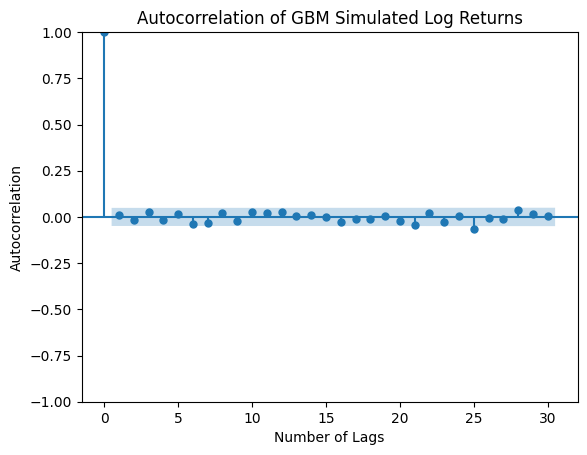

In [16]:
plot_acf(sim_log_returns, lags=30)
plt.title("Autocorrelation of GBM Simulated Log Returns")
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
plt.show()

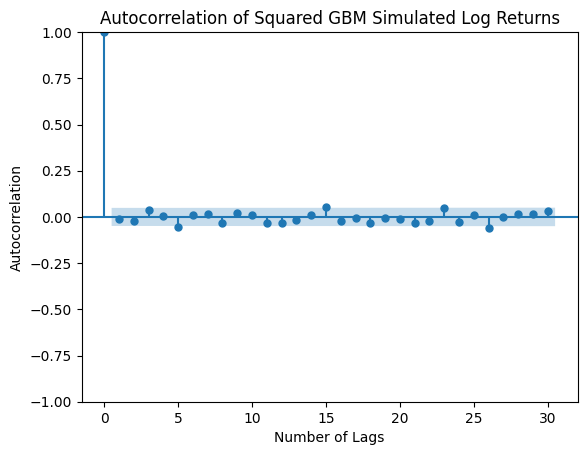

In [17]:
plot_acf(sim_log_returns**2, lags=30)
plt.title("Autocorrelation of Squared GBM Simulated Log Returns")
plt.xlabel("Number of Lags")
plt.ylabel("Autocorrelation")
plt.show()

The ACF plots of the GBM model show that neither returns nor squared returns show significant autocorellation across lags, consistent with the assumption of independent Gaussian increments with only isolated spikes, randomly fluctuating near zero. 

This contrasts sharply with the historical data, where the squared returns showed significant autocorellation with a clear decay pattern. The GBM model fails to model the persistent volatility dynamics present in the historical data. 

### Final Analysis GBM Model vs. Historical S&P-500 Data
Our GBM Model calibrated to the historical data is able to reproduce some first order properties:
 
 - Both the empirical returns and simulated returns lack strong long-range autocorrelation structure. Still, the empirical data exhibits noticeably larger short-lag fluctuations than the GBM simulations, suggesting deviations from the iid increment assumption. 
 
 - The GBM paths reproduced a similar scale of fluctuations. The resulting paths exhibited qualitatively plausible stochastic price behavior. 

However, the GBM model failed to reproduce some higher order statistical properties: 
- The model showed excess kurtosis close to 0, while the historical data had significant excess kurtosis >>0. The Gaussian increment assumption significantly underestimates the frequency of extreme market movements
- While the rolling volatility analysis of the historical data showed persistant periods of elevated and reduced volatility, the GBM simulations showed a much flatter rolling volatility curve with structureless fluctuations reflecting the models assumption of constant variance. 
- The empirical squared returns exhibited persistent positive autocorrelation with a marked decay structure, indicating volatility clustering and time-varying variance. The GBM model showed squared-return autocorrelations fluctuating near zero, consistent with independent increments and constant volatility.

The analysis suggests that financial time series cannot fully be characterized by low-order statistics such as mean and variance. Temporal dependence in volatility-related quantities constitues an important aspect of market dynamics absent from the classical GBM framework.

The observed differences in the simulated data vs. the historical S&P-500 data are caused directly by the assumptions of the GBM, particularily the assumptions of iid Gaussian increments and constant volatility. While these assumptions yield a mathematically elegant stochastic framework, they do not adequately reproduce the higher-order structure observed in empirical market data. 

Despite these limitations, the GBM remains an important baseline model due to its analytical simplicity and its central role in classical quantitative finance i.e. the derivation of the Black-Scholes framework. 

The observed persistence in volatility-related quantities naturally motivates more sophisticated stochastic models that incorporate time-varying or stochastic volatility such as GARCH.

This motivates us to the second part of this project, where we see if we can capture some of these higher order statistical properties through machine learning.

## Machine Learning Model to capture Higher-Order Structure

The analysis of the S&P-500 historical data compared with the GBM simulations indicates, that although return directions are difficult to predict, volatility-related quantities exhibit persistent temporal dependence absent from the GBM framework. This distinction motivates the transition from classical diffusion-based modeling towards machine learning approaches focused on predicting conditional volatility dynamics. 

